# Grundlagen der Cognitive Science 

## Perceptron Project

### Organisation

Like the first homework assignment (essay), this programming project is part of the material required to pass the module. 

Like the first homework assignment, each student will hand in their own copy of the notebook.
You are however strongly encouraged to form small groups to work on the notebooks!
Learning is often better together: help each other to develop and understand the material and code. 

You must hand in your essay and your notebook together at one of the Abgabetermine to pass the course.

**DEADLINE: see TUCaN**

### Procedure

The seminar time will mostly be used for you to work on the notebook in small groups. A tutor will be available to answer questions. Of course, you may choose to work on the assignments in your own time.

A loose schedule for the five weeks of the seminar for this component is:

- Week 1: Introduction to the perceptron (mini-lecture in class) and discussion. Introduction to the notebook
    <br>**Homework for this week**: Tasks 1 and 2.
- Week 2: Task 3 (start).
- Week 3: Task 3 (continue and finish).
    <br>**Homework for this week**: Read the paper by Medin and Schwanenfluegel
- Week 4: Introduction to Medin and Schwanenflugel (mini-lecture in class). Task 4.
- Week 5: Tasks 5 and 6. 

### Glossary

- *training set*: the collection of data you will use to learn weights. Each separate data entry is sometimes called a *trial*, an *exemplar*, an *observation* or a *data point*.
- *epoch*: One epoch corresponds to one complete pass through the training set. After one epoch, each example in the training set has had an opportunity to influence the model weights.

### Numpy functions you may find useful

- [numpy.array](https://numpy.org/doc/stable/reference/generated/numpy.array.html)
- [numpy.inner](https://numpy.org/doc/stable/reference/generated/numpy.inner.html)
- [numpy.ndarray.shape](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.shape.html)
- [numpy.empty](https://numpy.org/doc/stable/reference/generated/numpy.empty.html) and [numpy.empty_like](https://numpy.org/doc/stable/reference/generated/numpy.empty_like.html)

---

IMPORTANT: Fill in your name and Matrikelnummer in the cell below.

In [54]:
__name__ = "Mai-Lan Bui"
__matrikelnummer__ = 3583498

---

## Task 1 - Definition of a Perceptron

**Name and explain in your own words / mathematical notation the most important elements of the perceptron. What are they? What function do they fulfill?** 
<br> Write your answer in the cell below.


The Perceptron is a biological neuron model used in an artifical neural network. 
It makes decision based on inputs and weighting by summing them up and adding a bias.
Inputs (x1, x2, ...): Data values 
Weights (w1, w2, ...): Importance of each input
Weighted sum: Combines inputs into one value 
Bias: Shifts the decision boundary
Then an activation function converts the sum into output (0 'false' or 1 'true').
Output: Final prediction

## Task 2 - Determine weights for logical rules

Imagine a perceptron that has two inputs A and B. These can take values of either 1 (True) or 0 (False). For the inputs A and B our *activation* is $w_1*A + w_2*B+\theta$ ($\theta$ = theta). Note that the weights and the bias can be any real number (in particular: negative values are also possible). The perceptron should "fire" (return a 1) when the rule is satisfied, or else not fire (return a 0). This means that when we put the *activation* into our threshold function, we get 1 if $w_1*A + w_2*B+\theta >0$ and 0 otherwise (so if $w_1*A + w_2*B+\theta <= 0$). 

The different logical expressions below (2.1-2.4) all get two inputs, A and B, but show different output behavior (meaning, they fire and don't fire for different input-output combinations). For the input-output combination that each logical expression encodes, determine values for weights $w_1$ (for input A) and $w_2$ (for input B) and bias $\theta$.  You don't need to write code here; the goal is for you to think logically about what the weights and bias mean. As a solution, simply filling in suitable values for the weights and bias below is sufficient.

*Hint:* It could be useful to start with a truth table for each expression to understand the expression's behavior.

### Task 2.1

$A\wedge B$

### Task 2.2

$A \vee \neg B$

### Task 2.3

$(A \wedge B) \vee (\neg A \wedge B)$

### Task 2.4

$(A \wedge B) \vee (\neg A \wedge B) \vee (A \wedge \neg B)$

### Task 2.5

Now we add a third input C. As A and B it can have values of 1 (True) or 0 (False). Determine weights $w_1$ (for input A) and $w_2$ (for input B), $w_3$ (for input C) and bias $\theta$ to encode the following rule.

$(A\wedge B) \vee C$

## Task 3 - how to train your Perceptron

**Implement a Perceptron that learns the logical rule AND by training on data.**

To do this, you will sequentially build up a series of functions that will allow you to define and train a perceptron. The following graph gives an overview over the functions:

![Perceptron function "landscape"](./figures/perceptron_functions.png)

In [55]:
from typing import Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np

import perceptron_tests as tests

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Task 3.1 - Define the functions to train a perceptron

In this part you have to implement the functions you need to train a perceptron. The cells below alternate between:
- A cell with a function definition that currently does nothing (it just contains a `pass` statement). However, each function contains a docstring, that describes what the function is supposed to do and what its inputs (see *Args*) and outputs (see *Returns*) are. 
- A cell that calls a series of tests on your function.

**Your task now, is to implement the functions according to their descriptions.**

To check whether your functions work as intended you can run the test cells below each function cell. They call the function you wrote on some known input-output pairs, and use an `assert` statement to check whether the output of the function is as intended for the given inputs. (If you want to see the code of the tests, open `perceptron_tests.py`). 

If the function works as intended, the test will "pass" -- meaning it will not cause an error.
It should print the result of the function call, and say "test passed!".

If the function is not working as intended, then the test will give an `AssertionError`. This means that something is not working as intended in your function. It may be wrong, or it may just be providing outputs in an unintended form. Modify your code until all tests for each function pass. Do not modify the test cells.

*Hint:* Remember to re-run the cell that defines the function when you update the code -- Python will use the old version until you explicitly redefine the function.

Once all your functions are defined and tests pass, you will have the tools you need to train perceptrons on different datasets. We will use the functions in the next tasks.

In [ ]:
def compute_activation(inputs: np.ndarray, weights: np.ndarray, bias: float) -> Union[float, np.ndarray]:
    #skalarprodukt von weights und inputs berechnen // @ das selbe wie np.dot (Skalarprodukt)
    #dann bias addieren
    activation = inputs @ weights + bias 
    #ergebnis zurückgeben
    return activation
    """
    Compute the activation of the Perceptron.

    This function computes the activation of the Perceptron with given inputs, weights and bias.
    The activation is the sum of the weighted inputs plus the bias term.

    Hint: if possible, use your knowledge of numpy to avoid using a `for` loop in this function.

    Args:
        inputs (np.array): A numpy array containing the inputs to the perceptron,
                           assumed to be a vector containing one trial with
                           number of dimensions == len(inputs).
        weights (np.array): A numpy array containing the Perceptron's weights for each
                            input dimension. Should contain one entry per dimension
                            (i.e. is the same shape as the input array).
        bias (float): The value of the Perceptron's bias term. A scalar.

    Returns:
        Union[float, np.ndarray]: A float containing the Perceptron's activation.
    """
    pass

In [57]:
# Test cell - do not modify
tests.test_compute_activation_1(compute_activation)
tests.test_compute_activation_2(compute_activation)
tests.test_compute_activation_3(compute_activation)
tests.test_compute_activation_4(compute_activation)
tests.test_compute_activation_5(compute_activation)
tests.test_compute_activation_type(compute_activation)

test_compute_activation_1 result is 0.75

Test passed!
------------------

test_compute_activation_2 result is 0.25

Test passed!
------------------

test_compute_activation_3 result is 0.75

Test passed!
------------------

test_compute_activation_4 result is 1.5

Test passed!
------------------

test_compute_activation_5 result is -1.5

Test passed!
------------------

Testing return types...
Test passed!
Test passed!

------------------



In [58]:
def activation_function(activation: np.ndarray | float) -> np.ndarray:
    #np.where(Bedingung, Wert_wenn_wahr, Wert_wenn_falsch)
    #aktivierungswert >= 0 -> 1, sonst 0
    decision = np.where(activation > 0, 1, 0)

    return decision
    """
    Apply the activation function to a (set of) activation value(s)

    The activation function of the Perceptron is the Heaviside
    function (a step function).

    Args:
        activation (np.ndarray | float): The activation value(s) of the perceptron.
                Could be a scalar (i.e. one value) or a vector.

    Returns:
        np.ndarray: contains an integer (either 1 or 0) in each element.
    """
    pass

In [59]:
# Test cell - do not modify
tests.test_activation_function_1(activation_function)
tests.test_activation_function_2(activation_function)
tests.test_activation_function_3(activation_function)
tests.test_activation_function_4(activation_function)
tests.test_activation_function_type(activation_function)

test_activation_function_1 result is 0

Test passed!
------------------

test_activation_function_2 result is 1

Test passed!
------------------

test_activation_function_3 result is 0

Test passed!
------------------

test_activation_function_4 result is [0 0 1]

Test passed!
------------------

Testing return types...
Test passed!
Test passed!

------------------



In [60]:
def forward(inputs: np.ndarray, weights: np.ndarray, bias: float) -> np.ndarray:
    #Aktivierung mit der ersten Funktion berechnen
    activation = compute_activation(inputs, weights, bias)
    #Aktivierungswert mit der zweiten Funktion in eine Entscheidung umwandeln
    result = activation_function(activation)
    #Ergebnis zurückgeben
    return result
    """
    Compute the output of a Perceptron
    This function computes the output of a Perceptron (forward pass) with the provided weights and bias.

    Hint: use the compute_activation and activation_function functions in the body of this function.

    Args:
        inputs (np.ndarray): A numpy array containing the inputs to the perceptron,
                           assumed to be a vector containing one trial with
                           number of dimensions == len(inputs).
        weights (np.ndarray): A numpy array containing the Perceptron's weights for each
                            input dimension. Should contain one entry per dimension
                            (i.e. is the same shape as the input array).
        bias (float): The value of the Perceptron's bias term. A scalar.

    Returns:
        Union[float, np.ndarray]: A float or array containing the Perceptron's output as a float value
    """
    pass

In [61]:
# Test cell - do not modify
tests.test_forward_1(forward)
tests.test_forward_2(forward)
tests.test_forward_3(forward)
tests.test_forward_type(forward)

test_forward_1 result is 1

Test passed!
------------------

test_forward_2 result is 0

Test passed!
------------------

test_forward_3 result is 1

Test passed!
------------------

Testing return types...
Test passed!

------------------



In [62]:
def compute_delta_w(
    inputs: np.ndarray,
    target: float,
    output: float,
) -> Tuple[np.ndarray, float]:
    """
    Compute the change in weights and bias

    This function computes the change in weights and bias
    according to the learning rule for the Perceptron.

    Hint: to return a Tuple of some elements, you can just write
    `return element1, element2, ...`

    Similarly, to unpack the Tuple when calling the function,
    you can just write `element1, element2, ... = function_call()`

    Args:
        inputs (np.ndarray): A numpy array containing the inputs to the perceptron,
                           assumed to be a vector containing one trial with
                           number of dimensions == len(inputs).
        target (float): The correct output label for this trial. A scalar.
        output (float): The output of the Perceptron (its prediction for the
                           target label). Sometimes called y_hat in notation.

    Returns:
        Tuple[np.ndarray, float]: A two-element Tuple containing (1) the delta for the
                            weights and (2) the delta for the bias term.
    """
    #Fehler bestimmen 
    error = target - output
    #Änderung berechnen
    delta_w = error * inputs
    delta_bias = error
    #Paket zurückgeben
    return delta_w, delta_bias
    



In [63]:
# Test cell - do not modify
tests.test_compute_delta_w_1(compute_delta_w)
tests.test_compute_delta_w_2(compute_delta_w)
tests.test_compute_delta_w_3(compute_delta_w)
tests.test_compute_delta_w_4(compute_delta_w)
tests.test_compute_delta_w_type(compute_delta_w)

test_compute_delta_w_1 delta_w is [1. 1.]

test_compute_delta_w_1 delta_bias is 1.0

Test passed!
------------------

test_compute_delta_w_2 delta_w is [0. 0.]

test_compute_delta_w_2 delta_bias is 0.0

Test passed!
------------------

test_compute_delta_w_3 delta_w is [-1. -1.]

test_compute_delta_w_3 delta_bias is -1.0

Test passed!
------------------

test_compute_delta_w_4 delta_w is [0. 0.]

test_compute_delta_w_4 delta_bias is 0.0

Test passed!
------------------

Testing return types...
Test passed!

------------------



In [64]:
def update_weights(
    inputs: np.ndarray,
    target: float,
    output: float,
    weights: np.ndarray,
    bias: float,
) -> Tuple[np.ndarray, float]:
    #Korrektur Werte berechnen 
    #vorherige Funktion aufrufen (def: compute_delta_w)
    delta_w, delta_bias = compute_delta_w(inputs, target, output)
    #neue Werte berechnen
    new_weights = weights + delta_w
    new_bias = bias + delta_bias

    return new_weights, new_bias
    """
    Update the Perceptron's weights and bias

    This function computes the new weights and bias for
    the perceptron based on its prediction and the true class
    label, using the Perceptron's learning rule.

    Args:
        inputs (np.ndarray): A numpy array containing the inputs to the perceptron,
                           assumed to be a vector containing one trial with
                           number of dimensions == len(inputs).
        target (float): The correct output label for this trial. A scalar.
        output (float): The output of the Perceptron (its prediction for the
                           target label). Sometimes called y_hat in notation.
        weights (np.ndarray): A numpy array containing the Perceptron's weights for each
                            input dimension. Should contain one entry per dimension.
        bias (float): The value of the Perceptron's bias term. A scalar.

    Returns:
        Tuple[np.ndarray, float]: A two-element Tuple containing (1) the updated
                            weights and (2) the updated bias.
    """
   

In [65]:
# Test cell - do not modify
tests.test_update_weights_1(update_weights)
tests.test_update_weights_2(update_weights)
tests.test_update_weights_3(update_weights)
tests.test_update_weights_4(update_weights)
tests.test_update_weights_type(update_weights)

test_update_weights_1 new_weights is [0.]

test_update_weights_1 new_bias is 0.0

Test passed!
------------------

test_update_weights_2 new_weights is [1.]

test_update_weights_2 new_bias is 1.0

Test passed!
------------------

test_update_weights_3 new_weights is [0. 1. 1. 1.]

test_update_weights_3 new_bias is 1.0

Test passed!
------------------

test_update_weights_4 new_weights is [1. 1. 1. 1.]

test_update_weights_4 new_bias is -1.0

Test passed!
------------------

Testing return types...
Test passed!

------------------



In [66]:
def train_one_trial(
    inputs: np.ndarray, target: float, weights: np.ndarray, bias: float
) -> Tuple[np.ndarray, float, np.ndarray|float]:
    #output berechnen (vorhersage)
    output = forward(inputs, weights, bias)
    #neue gewichte und bias berechnen
    #output wird hier mit übergeben
    new_weights, new_bias = update_weights(inputs, target, output, weights, bias)
    #rückgabe der neuen werte und output
    return new_weights, new_bias, output

    """
    Train a Perceptron for a single trial (data example)

    This function computes the output for the Perceptron based on the provided
    inputs, weights and biases, then returns updated weights based on the
    Perceptron's learning rule.

    **Note that the output is defined by the perceptron's state *before*
    the weight update.**

    Args:
        inputs (np.ndarray): A numpy array containing the inputs to the perceptron,
                           assumed to be a vector containing one trial with
                           number of dimensions == len(inputs).
        target (float): The correct output label for this trial. A scalar.
        weights (np.ndarray): A numpy array containing the Perceptron's weights for each
                            input dimension. Should contain one entry per dimension.
        bias (float): The value of the Perceptron's bias term. A scalar.

    Returns:
        Tuple[np.ndarray, float, float | np.ndarray]: The results of this trial's output as
                                 a Tuple of length 3 containing
                                 (1) the weights after training,
                                 (2) the bias after training,
                                 (3) the output of the perceptron for this trial
    """
    pass

In [67]:
# Test cell - do not modify
tests.test_train_one_trial_1(train_one_trial)
tests.test_train_one_trial_2(train_one_trial)
tests.test_train_one_trial_3(train_one_trial)
tests.test_train_one_trial_4(train_one_trial)
tests.test_train_one_trial_5(train_one_trial)
tests.test_train_one_trial_type(train_one_trial)

test_train_one_trial_1 weights is [0. 1.]

test_train_one_trial_1 bias is 1.0

test_train_one_trial_1 output is 0

Test passed!
------------------

test_train_one_trial_2 weights is [0. 1.]

test_train_one_trial_2 bias is 0.0

test_train_one_trial_2 output is 1

Test passed!
------------------

test_train_one_trial_3 weights is [0. 1.]

test_train_one_trial_3 bias is -1.0

test_train_one_trial_3 output is 1

Test passed!
------------------

test_train_one_trial_4 weights is [1. 1.]

test_train_one_trial_4 bias is -1.0

test_train_one_trial_4 output is 0

Test passed!
------------------

test_train_one_trial_5 weights is [0. 1.]

test_train_one_trial_5 bias is 0.0

test_train_one_trial_5 output is 1

Test passed!
------------------

Testing return types...
Test passed!

------------------



Now, we need a way to compute the average error of our perceptron over a series of trials.

For this, implement a `compute_error_rate` function, that computes the mean absolute difference between the targets and the outputs of the perceptron. In mathematical notation:
$\frac{1}{n} \sum_{i=1}^n |t_i-o_i|$

In [73]:
def compute_error_rate(targets: np.ndarray, output: np.ndarray) -> float:
    #absoluten Fehler berechnen (np.abs) 
    #durschnitt berechnen (np.mean)
    error_proportion = np.mean(np.abs(targets - output))
    
    return error_proportion
    """
    Compute the error proportion (Mean absolute error).

    This function computes the mean absolute difference between
    a vector of targets and a vector of outputs (predictions
    for the target label). Targets and outputs are assumed to be
    binary (either 0 or 1).

    Hint: Try to avoid using a "for" loop here and instead use 
          appropriate numpy functions.

    Args:
        targets (np.ndarray): A numpy array containing the binary true labels.
        output (np.ndarray): A numpy array containing the predictions.

    Returns:
        float: The proportion of errors between output and target.
    """
    pass

In [74]:
# Test cell - do not modify
tests.test_compute_error_rate_1(compute_error_rate)
tests.test_compute_error_rate_2(compute_error_rate)
tests.test_compute_error_rate_3(compute_error_rate)
tests.test_compute_error_rate_type(compute_error_rate)

test_compute_error_rate_1 result is 0.4

Test passed!
------------------

test_compute_error_rate_2 result is 0.5555555555555556

Test passed!
------------------

test_compute_error_rate_3 result is 0.25

Test passed!
------------------

Testing return types...
Test passed!

------------------



In [77]:
def train_one_epoch(
    inputs: np.ndarray,
    targets: np.ndarray,
    weights: np.ndarray,
    bias: float,
    verbose: bool = True,
) -> Tuple[np.ndarray, float, np.ndarray, float]:
    all_outputs = [] # sammlen der outputs
    for i in range(len(inputs)): # durch alle trials iterieren
        current_input = inputs[i]
        current_target = targets[i]
        # trainieren und erhalten der neuen werte
        weights, bias, output = train_one_trial(current_input, current_target, weights, bias)
        all_outputs.append(output) # output speichern
    all_outputs = np.array(all_outputs) # in numpy array umwandeln
    error_rate = compute_error_rate(targets, all_outputs) # fehler berechnen
    #status ausgeben (wenn verbose true)
    if verbose:
        print(f"Finished epoch with weights: {weights}, bias: {bias}, error rate: {error_rate}")
        #Rückgabe der Ergebnisse
    return weights, bias, all_outputs, error_rate
    """
    Train a Perceptron for one epoch

    This function should train the weights and biases of
    a perceptron over one epoch (one run through all the data).

    The weights and bias will be updated *after* each training
    example (data point or trial). This means that the average
    error computed over the epoch does not reflect the error
    that will result from the final set of weights. For this,
    a new epoch is required.

    Note that definitions of input arguments provided below
    are common to other functions unless noted otherwise.

    Args:
        inputs (np.ndarray): A numpy array containing the inputs to the perceptron.
                           The inputs are often called "X" in notation. Since we
                           update over multiple trials (data examples) now, the
                           input is a matrix of shape number_of_trials x input_dimension.
                           This means that the rows are assumed to be "trials"
                           (data examples) and the columns are the different input dimensions
                           x_1, x_2 etc. If just one trial is passed, it should be passed
                           as a matrix of shape 1 x input_dimension.
        targets (np.ndarray): The correct output labels. Often called "Y" in notation.
                            There should be one entry per row of X.
        weights (np.ndarray): A numpy array containing the Perceptron's weights for each
                            input dimension. Should contain one entry per dimension.
        bias (float): The value of the Perceptron's bias term. A scalar.
        verbose (bool, optional): If True, print information about the results of training
                                  in this epoch, including weights and bias at the end of
                                  the epoch, and also the overall error in the epoch.
                                  Defaults to True.

    Returns:
        Tuple[np.ndarray, float, np.ndarray, float]: The results of this epoch output as
                                 a Tuple of length 4 containing
                                 (1) the weights after training,
                                 (2) the bias after training,
                                 (3) the outputs of the perceptron on each trial and
                                 (4) the overall error rate for the epoch.
    """
    pass
    

In [78]:
# Test cell - do not modify
tests.test_train_one_epoch_1(train_one_epoch)
tests.test_train_one_epoch_2(train_one_epoch)
tests.test_train_one_epoch_3(train_one_epoch)
tests.test_train_one_epoch_4(train_one_epoch)
tests.test_train_one_epoch_type(train_one_epoch)

test_train_one_epoch_1 weights is [0. 1.]

test_train_one_epoch_1 bias is 1.0

test_train_one_epoch_1 epoch_outputs is [0]

test_train_one_epoch_1 epoch_error is 1.0

Test passed!
------------------

test_train_one_epoch_2 weights is [0. 1.]

test_train_one_epoch_2 bias is 0.0

test_train_one_epoch_2 epoch_outputs is [0 1]

test_train_one_epoch_2 epoch_error is 1.0

Test passed!
------------------

test_train_one_epoch_3 weights is [1. 1.]

test_train_one_epoch_3 bias is 1.0

test_train_one_epoch_3 epoch_outputs is [0 1 0]

test_train_one_epoch_3 epoch_error is 1.0

Test passed!
------------------

test_train_one_epoch_4 weights is [1. 1.]

test_train_one_epoch_4 bias is 1.0

test_train_one_epoch_4 epoch_outputs is [0 1 0 1]

test_train_one_epoch_4 epoch_error is 0.75

Test passed!
------------------

Testing return types...
Test passed!

------------------



### Task 3.2 - Train the AND function

Using the functions above, implement a perceptron that learns the logical rule AND ($\wedge$). 

First, define a data set (using numpy arrays) that defines the desired rule (i.e. the input-output pairs). 
Your input data should be a matrix with two dimensions. Each row should be one data exemplar (one input combination) and each column one input variable (for our logical expression: A and B). The targets are then a one-dimensional vector with one output value for each row in the input matrix.


In [80]:
# In this cell, you should initialise a batch of data
# that defines the desired rule. Specify a numpy array
# of input values, where each row is a data point and each column
# is an input (A and B).
#AND-Rule
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])

# Now specify a numpy array targets, which contains the target labels
# ("correct decisions") for each row specified in inputs.

#dazugehörige Zielwerte für AND-Rule
targets = np.array([0, 0, 0, 1])

#Kontrolle der Eingaben
inputs, targets

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 0, 0, 1]))

Now initialise the weights and bias terms to be all zero, and compute the initial predictions and errors. 

In [79]:
# fill your code in here.
weights = np.array([0.0, 0.0])
bias = 0.0

Now train the model for 10 epochs, by writing a `for` loop over the function `train_one_epoch`.

In [81]:
# fill your code in here. Use a print() statement to print out
# useful information within the loop and also at the end.

print(f"Starting training...")

num_epochs = 10

for epoch in range(num_epochs):
    #Funktion wird aufgerufen und durch neue Werte ersetzt
    weights, bias, epoch_outputs, error_rate = train_one_epoch(
        inputs, targets, weights, bias, verbose=False
    )
    #Nützliche Informationen ausgeben
    print(f"Epoch {epoch + 1}: Error Rate: {error_rate: .2f}")

    #Endergenis nach 10 Ausgaben 
    print(f"Training finished. Final weights: {weights}, bias: {bias}, error rate: {error_rate}")

Starting training...
Epoch 1: Error Rate:  0.25
Training finished. Final weights: [1. 1.], bias: 1.0, error rate: 0.25
Epoch 2: Error Rate:  0.75
Training finished. Final weights: [2. 1.], bias: 0.0, error rate: 0.75
Epoch 3: Error Rate:  0.75
Training finished. Final weights: [2. 1.], bias: -1.0, error rate: 0.75
Epoch 4: Error Rate:  0.50
Training finished. Final weights: [2. 2.], bias: -1.0, error rate: 0.5
Epoch 5: Error Rate:  0.25
Training finished. Final weights: [2. 1.], bias: -2.0, error rate: 0.25
Epoch 6: Error Rate:  0.00
Training finished. Final weights: [2. 1.], bias: -2.0, error rate: 0.0
Epoch 7: Error Rate:  0.00
Training finished. Final weights: [2. 1.], bias: -2.0, error rate: 0.0
Epoch 8: Error Rate:  0.00
Training finished. Final weights: [2. 1.], bias: -2.0, error rate: 0.0
Epoch 9: Error Rate:  0.00
Training finished. Final weights: [2. 1.], bias: -2.0, error rate: 0.0
Epoch 10: Error Rate:  0.00
Training finished. Final weights: [2. 1.], bias: -2.0, error rate: 

**Answer the following questions in the markdown cell below:**

1. What is the final performance of the model? 
2. What are the final weights? 
3. How does the performance change over epochs? 
4. Can a perceptron learn the logical rule AND?

1. The final error rate performance of the model is "0.0". 
2. The final weights are: [2. 1.] and the bias is -2.0.
3. The performance began with an error rate of 0.25 and after 5 epoches it sank to 0.
4. A perpectron can learn the logical AND rule because the classes (0 and 1) are linearly separable. A single straight line can perfectly divide the inputs that result in 0 from those that result in 1.

### Task 3.3. - Training in different order

Training the Perceptron as above is deterministic: starting with all weights set to zero and looping over the dataset N times in the same order produces the same result each time. (Confirm this by re-running the cells above multiple times -- remember to set the weights back to zero).

Now, we add randomness in the training by shuffling the order of the training exemplars on each epoch. The first step to do this is to write a function to shuffle the input and target arrays.
Since this is a bit advanced, we just give you this function.

In [120]:
# This function already works as intended - do not modify this cell
def shuffle_arrays(
    inputs: np.ndarray, targets: np.ndarray, seed: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Shuffle the order of exemplars in input and target arrays

    This function shuffles the order of the exemplars (observations)
    in the data inputs and targets. Each call to this function should
    yield a random re-ordering of the rows of the input matrix and a
    matching re-ordering of the entries of the targets vector.

    More detail:
    1. We use numpy's random package. See
    https://numpy.org/doc/stable/reference/random/index.html#random-quick-start
    2. See e.g. https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html

    Args:
        inputs (np.ndarray): A numpy array containing the inputs to the perceptron.
                           The inputs are often called "X" in notation. If a
                           matrix is passed, the rows are assumed to be "trials"
                           (data examples) and columns are different input dimensions
                           x_1, x_2 etc. If a vector is passed, it is assumed to be
                           one trial with number of dimensions == len(inputs).
        targets (np.ndarray): The correct output labels. Often called "Y" in notation.
                            There should be one entry per row of X if X is a matrix.
        seed (Optional[int], optional): If an integer is provided, this
                            will be used as the seed for the random number generator
                            to yield deterministic results. If None (the default),
                            will use the default behaviour of numpy's random number
                            generator.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A two-element Tuple containing the re-ordered arrays.
    """
    # copy arrays to make sure we don't have unintended side-effects:
    inputs = inputs.copy()
    targets = targets.copy()
    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)

    p = rng.permutation(len(targets))
    return inputs[p], targets[p]

In [121]:
# note that these tests might fail anyway due to different
# OS versions, python versions and what they cause with random seeds.
# since we're giving you this function, it should work as intended
# even if the tests fail.
tests.test_shuffle_arrays_1(shuffle_arrays)
tests.test_shuffle_arrays_2(shuffle_arrays)
tests.test_shuffle_arrays_3(shuffle_arrays)
tests.test_shuffle_arrays_type(shuffle_arrays)

test_shuffle_arrays_1 inputs_shuffled is [[5 6 7 8]
 [1 2 3 4]]

test_shuffle_arrays_1 targets_shuffled is [0 1]

Test passed!
------------------

test_shuffle_arrays_2 inputs_shuffled is [[1 2 3 4]
 [5 6 7 8]]

test_shuffle_arrays_2 targets_shuffled is [1 0]

Test passed!
------------------

test_shuffle_arrays_3 inputs_shuffled is [[ 9 10 11 12]
 [ 5  6  7  8]
 [ 1  2  3  4]]

test_shuffle_arrays_3 targets_shuffled is [2 0 1]

Test passed!
------------------

Testing return types...
Test passed!

------------------



Now that we can shuffle arrays, let's use this in a new function in which we train multiple epochs. Read the function description carefully, since this function does slightly different things depending on the given input parameters.

**Implement the `train_n_epochs` function.**

In [122]:
def train_n_epochs(
    n_epochs: int,
    inputs: np.ndarray,
    targets: np.ndarray,
    weights: np.ndarray,
    bias: float,
    verbose: bool = True,
    shuffle: bool = True,
    seed: Optional[int] = None,
) -> Tuple[np.ndarray, float, np.ndarray]:
    """
    Train over a number of epochs

    This function trains a perceptron over a number of
    epochs (iterations over the training data) and returns
    the final weights and bias. Optionally the function can
    also shuffle the data array on each epoch, to provide
    exemplars in a random order.

    Args:
        n_epochs (int): The number of epochs to iterate over.
        inputs (np.ndarray): A numpy array containing the inputs to the perceptron.
                           The inputs are often called "X" in notation. If a
                           matrix is passed, the rows are assumed to be "trials"
                           (data examples) and columns are different input dimensions
                           x_1, x_2 etc. If a vector is passed, it is assumed to be
                           one trial with number of dimensions == len(inputs).
        targets (np.ndarray): The correct output labels. Often called "Y" in notation.
                            There should be one entry per row of X if X is a matrix.
        weights (np.ndarray): A numpy array containing the Perceptron's weights for each
                            input dimension. Should contain one entry per dimension.
        bias (float): The value of the Perceptron's bias term. A scalar.
        verbose (bool, optional): If True, print information about the results of training,
                                including weights and bias at the end of
                                the epoch, and also the overall error in the epoch.
                                Should also be passed to train_one_epoch.
                                Defaults to True.
        shuffle (bool, optional): If True, randomly shuffle the order of data exemplars
                                on each Epoch separately. Defaults to True.
        seed (Optional[int], optional): Passed to the shuffle_arrays function.
                            If an integer is provided, this
                            will be used as the seed for the random number generator
                            to yield deterministic results. If None (the default),
                            will use the default behaviour of numpy's random number
                            generator.


    Returns:
        Tuple[np.ndarray, float, np.ndarray]: The results of training over the epochs (i.e.
                                the final result as a Tuple of length 3 containing
                                (1) the weights after training,
                                (2) the bias after training,
                                (3) a vector containing the error rate for each epoch
    """
    #Liste für Fehlerwerte initialisieren
    error_rates = []
    for epoch in range(n_epochs):
        #Daten ggf. mischen
        if shuffle:
            inputs, targets = shuffle_arrays(inputs, targets, seed)
    
        #Funktion aufrufen und neue Werte erhalten
        weights, bias, epoch_outputs, error_rate = train_one_epoch(
            inputs, targets, weights, bias, verbose
        )
        #Fehlerwert speichern
        error_rates.append(error_rate)
    return weights, bias, np.array(error_rates)

In [123]:
tests.test_train_n_epochs_1(train_n_epochs)
tests.test_train_n_epochs_2(train_n_epochs)
tests.test_train_n_epochs_type(train_n_epochs)

test_train_n_epochs_1 weights is [0.5 1. ]

test_train_n_epochs_1 epoch_errors is [1.  0.5 1. ]

Test passed!
------------------

test_train_n_epochs_2 weights is [1. 1.]

test_train_n_epochs_2 epoch_errors is [0.5 0.5 1. ]

Test passed!
------------------

Testing return types...
Test passed!

------------------



**Now, train 15 independent perceptrons for 10 epochs each on the "AND" rule.** They can all start with weights and bias values of 0, but should learn from the data in a different order.
Store the error rate in each epoch for each perceptron in a 2D numpy array called `error_mat`, where each column is an epoch and each row is one of the perceptrons.

In [ ]:
# write your code here. Be sure to name your array error_mat.
# vorbereitungen 
n_perceptrons = 15
n_epochs = 10
error_mat = [] #sammlen der fehlerwerte
for i in range(n_perceptrons):
    #initialisieren der gewichte und bias
    weights = np.array([0.0, 0.0])
    bias = 0.0
    #trainieren des perceptrons
    weights, bias, error_rates = train_n_epochs(
        n_epochs,
        inputs,
        targets,
        weights,
        bias,
        verbose=False, #keine ausgabe
        shuffle=True,   #daten mischen
        seed=i #unterschiedliche seeds für verschiedene perceptrons
    )
    error_mat.append(error_rates) #fehlerwerte speichern
error_mat = np.array(error_mat) #in numpy array umwandeln
print(error_mat)

[[0.25 0.75 0.5  0.25 0.   0.   0.   0.   0.   0.  ]
 [0.25 0.75 0.75 0.5  0.25 0.   0.   0.   0.   0.  ]
 [0.75 0.5  0.5  0.   0.   0.   0.   0.   0.   0.  ]
 [0.75 0.25 0.25 0.25 0.5  0.25 0.25 0.25 0.25 0.  ]
 [0.75 0.5  0.5  0.5  0.25 0.   0.   0.   0.   0.  ]
 [0.75 0.25 0.25 0.25 0.5  0.25 0.25 0.25 0.25 0.  ]
 [0.75 0.5  0.25 0.5  0.25 0.5  0.25 0.   0.   0.  ]
 [0.25 0.75 0.25 0.   0.   0.   0.   0.   0.   0.  ]
 [0.75 0.25 0.25 0.25 0.5  0.25 0.25 0.25 0.25 0.  ]
 [0.75 0.5  0.5  0.25 0.5  0.   0.   0.   0.   0.  ]
 [0.5  0.25 0.5  0.25 0.5  0.25 0.25 0.25 0.25 0.  ]
 [0.75 0.25 0.5  0.5  0.25 0.5  0.25 0.   0.   0.  ]
 [0.5  0.75 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.75 0.25 0.25 0.25 0.5  0.25 0.25 0.25 0.25 0.  ]
 [0.75 0.25 0.25 0.25 0.5  0.25 0.25 0.25 0.25 0.  ]]


Finally, let's plot the learning curves -- error rates as a function of epoch, for each perceptron and the average.
I provide a function below to do this. Just run the next two cells to see the results.

In [125]:
# This function already works as intended - do not modify this cell
def plot_learning_curve(error_matrix: np.ndarray) -> None:
    """
    A function to plot a set of learning curves

    Take a matrix containing error rate as a function
    of epoch for each of n perceptrons, and draw a plot
    where each perceptron is a semitransparent grey line
    and the average performance is shown in blue.

    Args:
        error_matrix (np.ndarray): A matrix containing the
                error rates of perceptron(s) as a function
                of epoch, with epochs in columns and each
                independent perceptron in rows.
    """
    ax = plt.axes()
    x = np.arange(1, error_matrix.shape[1] + 1)

    for p in range(error_matrix.shape[0]):
        ax.plot(x, error_matrix[p, :], color="0.5", alpha=0.25)

    ax.plot(x, error_matrix.mean(axis=0), color="b", label="Mean error rate")
    caption = "Grey lines show individual perceptron error rates on shuffled data. Blue line shows mean error rate."
    plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment="left", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Error rate")
    ax.set_ylim(-0.1, 1.1)

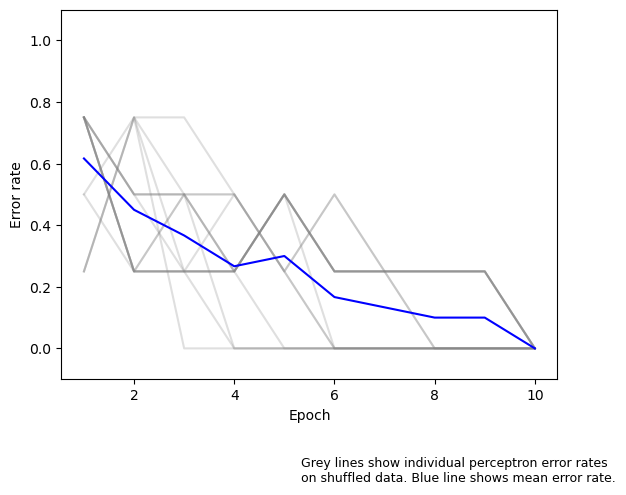

In [126]:
# Run this cell to see how the error rate develops over time for the different perceptrons
plot_learning_curve(error_mat)

**Answer the following question in the markdown cell below:**

Now that we removed some of the determinism by shuffling the data in each epoch, how do the different perceptrons differ in their learning? (Describe what you see in the plot and compare to your answers in task 3.2)

The learning process becomes stochastic, by shuffling the data in each epoch. In the plot there are many individual path for each perceptrons. While the error rate in Task 3.2 decreased identically for every run, here we see clear differences in the learning speed of individual modes (grey lines). Some perceptrons reach an error rate of 0.0 very quickly (e.g. epoch 3), while others show a "zig-zag" pattern where the error temporarily increases before dropping again. The blue line shows a steady downward trend, illustrating the general learning capability of the algorithm. All models reach an error rate of 0.0, proving that the perceptron can learn the AND rule regardless of the data sequences. 

## Task 4 - Experiments with the Perceptron

Now, we want to see whether the perceptron learns and performs similarly to humans in a categorisation task. 

In the following, an experiment by Medin and Schwanenflugel (1981) will be described. The paper can be downloaded from Moodle. The main focus is on experiment 1 in the paper. 

### Task 4.1

Describe the hypothesis that was developed and tested with experiment 1.

The hypothesis tested was wether linearly separable (LS) categories are easier for humans to learn than categories that are not-linearly separable (NLS).
This was based on independent cue models, which predict that humans categorize by summing evidence from individual features. A process that only works for linearly separable structures. The researchers also considered relational coding models. It suggest that the specific similarity between exemplars is more important than linear separability itself.

### Task 4.2

Describe the experiment set-up and procedure of experiment 1. How many participants were there? What was their task? How many trials did they do? What was measured?

For the experiment 64 undergraduates (male and female) attending the University of Illinois participated in this experiment.
The participants were randomly assigned to either the LS or NLS group and they had to correctly classify the stimuli of cards to either category A or B. 
The training stimuli were presented in runs of 8 cards each. The cards were shown in a random order and participants received feedback, whether their classification was correct or not.
The participant had to complete an entire run without errors or until the list had been presented for an maximum of 16 runs. 
The performance was measured by the total numbers of errors made until the learning criterion was met.
The LS group averaged 33.3 errors and the NLS group averaged 30.9 errors. 

### Task 4.3

Describe the stimuli used in experiment 1. How exactly do the stimuli differ and what do they look like? 

The stimuli consisted of cards featuring geometric forms.
The forms varied in 4 dimensions: color ( red or blue), form (circle or equilateral triangle), number/position (a single form (centered) or two forms (one on each half of the card)) or size (1.25 cm or 2.5 cm). 
The design allowed for a total of 16 stimuli, which were represented as 4 dimensional binary vectors to test the LS of the categories.

The stimuli from experiment 1 are shown again here. These tables correspond exactly to the tables shown in the paper.

<h3>Class 1 - Linearly Separable</h3>
<br><br>

<div style="margin: 1; cellspacing:10; width: 800px; display: block;">						
<table style="float:left; width:390px;">
  <tr>
    <th class="tg-031e" colspan="5"><center>CATEGORY A</center><br></th>
  </tr>
  <tr>
    <th class="tg-031e"></th>
    <th class="tg-031e" colspan="4"><center>Dimensions</center></th>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>Exemplar</b></center></td>
    <td class="tg-031e" colspan="4"></td>
  </tr>
  <tr>
    <td class="tg-031e"></td>
    <td class="tg-031e"><center><b>D1</b></center></td>
    <td class="tg-031e"><center><b>D2</b></center></td>
    <td class="tg-031e"><center><b>D3</b></center></td>
    <td class="tg-s6z2"><center><b>D4</b></center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A1</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A2</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A3</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A4</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
</table>
</div>
<div style="margin: 1;  cellspacing:10; width: 800px; display: block;">	
  <table style="float:right; width:390px;">
    <tr>
    <th class="tg-031e" colspan="5"><center>CATEGORY B</center><br></th>
  </tr>
  <tr>
    <th class="tg-031e"></th>
    <th class="tg-031e" colspan="4"><center>Dimensions</center></th>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>Exemplar</b></center></td>
    <td class="tg-031e" colspan="4"></td>
  </tr>
  <tr>
    <td class="tg-031e"></td>
    <td class="tg-031e"><center><b>D1</b></center></td>
    <td class="tg-031e"><center><b>D2</b></center></td>
    <td class="tg-031e"><center><b>D3</b></center></td>
    <td class="tg-s6z2"><center><b>D4</b></center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B1</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B2</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B3</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B4</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
</table>
</div>

<h3>Class 2 - Not Linearly Separable</h3>
<br><br>

<div style="margin: 1; cellspacing:10; width: 800px; display: block;">						
<table style="float:left; width:390px;">
  <tr>
    <th class="tg-031e" colspan="5"><center>CATEGORY A</center><br></th>
  </tr>
  <tr>
    <th class="tg-031e"></th>
    <th class="tg-031e" colspan="4"><center>Dimensions</center></th>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>Exemplar</b></center></td>
    <td class="tg-031e" colspan="4"></td>
  </tr>
  <tr>
    <td class="tg-031e"></td>
    <td class="tg-031e"><center><b>D1</b></center></td>
    <td class="tg-031e"><center><b>D2</b></center></td>
    <td class="tg-031e"><center><b>D3</b></center></td>
    <td class="tg-s6z2"><center><b>D4</b></center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A1</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A2</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A3</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>A4</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
</table>
</div>
<div style="margin: 1;  cellspacing:10; width: 800px; display: block;">	
  <table style="float:right; width:390px;">
    <tr>
    <th class="tg-031e" colspan="5"><center>CATEGORY B</center><br></th>
  </tr>
  <tr>
    <th class="tg-031e"></th>
    <th class="tg-031e" colspan="4"><center>Dimensions</center></th>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>Exemplar</b></center></td>
    <td class="tg-031e" colspan="4"></td>
  </tr>
  <tr>
    <td class="tg-031e"></td>
    <td class="tg-031e"><center><b>D1</b></center></td>
    <td class="tg-031e"><center><b>D2</b></center></td>
    <td class="tg-031e"><center><b>D3</b></center></td>
    <td class="tg-s6z2"><center><b>D4</b></center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B1</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B2</b></center></td>
    <td class="tg-031e"><center>1</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B3</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>0</center></td>
  </tr>
  <tr>
    <td class="tg-031e"><center><b>B4</b></center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-031e"><center>0</center></td>
    <td class="tg-s6z2"><center>1</center></td>
  </tr>
</table>
</div>

### Task 4.4

Extract the data (represent it in python code) shown in the tables from experiment 1, so that we can use it for the following tasks.

Hint: create separate variables for the inputs and for the targets of class 1 and class 2.

In [130]:
# fill in your code here
import numpy as np
#Group 1: Linearly Separable (LS)
#Dimensions: D1 =  color, D2= shape, D3 = number, D4 = size
inputs_class1 = np.array([
    [1,0, 1, 1], #A1
    [1,0, 1, 0], #A2
    [1,1, 0, 1], #A3
    [0,1, 1, 0], #A4
    [1,0, 0, 1], #B1
    [0,0, 1, 0], #B2
    [0,1, 0, 0], #B3
    [0,0, 0, 1], #B4
]) 
targets_class1 = np.array([1,1,1,1,0,0,0,0])

#Group 2: Not Linearly Separable (NLS)
inputs_class2 = np.array([
    [1,0,0,0], #A1
    [0,1,1,1], #A2
    [1,1,1,0], #A3
    [1,0,1,1], #A4
    [0,1,1,0], #B1
    [1,0,0,1], #B2
    [0,0,0,0], #B3
    [0,0,0,1], #B4
])
targets_class2 = np.array([1,1,1,1,0,0,0,0])

### Task 4.5

Use the data to train Perceptrons on the linearly separable class (Class 1). Make use of the functions you defined above.

Train the Perceptrons as the participants were trained in the study by Medin and Schwanenflugel (1981):

1. Set the number of epochs according to the experiment. 
2. Train the same number of perceptrons as there were participants. 
3. Present the exemplars in a random order.

In [ ]:
# fill in your code here. Name your output `error_mat` as above.
error_mat = [] #sammlen der fehlerwerte
n_perceptrons = 32 #participants per group
n_epochs = 16 #max runs

for i in range(n_perceptrons):
    #initialisieren der gewichte und bias
    weights = np.array([0.0, 0.0, 0.0, 0.0])
    bias = 0.0
    #LS Gruppe
    inputs = inputs_class1
    targets = targets_class1
    #simulieren der perceptrons
    weights, bias, error_rates = train_n_epochs(
        n_epochs,
        inputs,
        targets,
        weights,
        bias,
        verbose=False, #keine ausgabe der epochen
        shuffle=True, #zufällige reihenfolge der karten
        seed=i #unterschiedliche seeds für verschiedene perceptrons
    )
    error_mat.append(error_rates) #fehlerwerte speichern
error_mat = np.array(error_mat) #in numpy array umwandeln
print(error_mat)



[[0.625 0.25  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.625 0.25  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.375 0.25  0.5   0.5   0.25  0.25  0.125 0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.375 0.5   0.5   0.25  0.25  0.125 0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.625 0.5   0.375 0.25  0.5   0.125 0.25  0.25  0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.75  0.625 0.125 0.25  0.25  0.375 0.25  0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.875 0.25  0.375 0.25  0.125 0.375 0.375 0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.75  0.375 0.5   0.125 0.5   0.125 0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.875 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.875 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.5   0.25  0.5   

Now, visualise the learning curves of the perceptrons in this experiment.

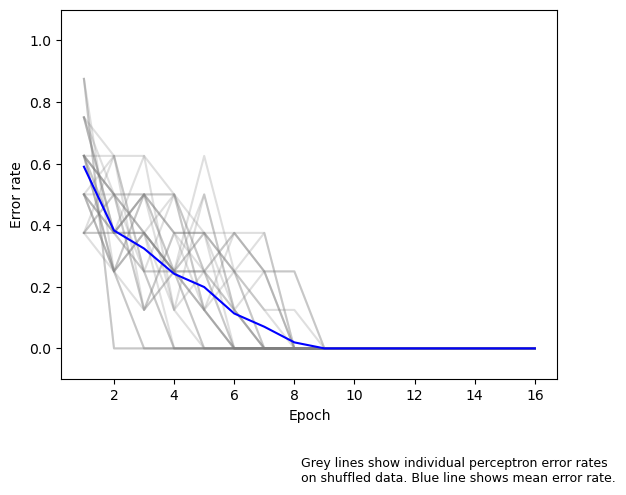

In [153]:
plot_learning_curve(error_mat)

### Task 4.6

Repeat Task 4.5 with the *non-* linearly separable class (Class 2). 

In [ ]:
# fill in your code here.
error_mat = [] #sammlen der fehlerwerte
n_perceptrons = 32 #participants per group
n_epochs = 16 #max runs

for i in range(n_perceptrons):
    #initialisieren der gewichte und bias
    weights = np.array([0.0, 0.0, 0.0, 0.0])
    bias = 0.0
    #LS Gruppe
    inputs = inputs_class2
    targets = targets_class2
    #simulieren der perceptrons
    weights, bias, error_rates = train_n_epochs(
        n_epochs,
        inputs,
        targets,
        weights,
        bias,
        verbose=False, #keine ausgabe der epochen
        shuffle=True, #zufällige reihenfolge der karten
        seed=i #unterschiedliche seeds für verschiedene perceptrons
    )
    error_mat.append(error_rates) #fehlerwerte speichern
error_mat = np.array(error_mat) #in numpy array umwandeln
print(error_mat)


[[0.75  0.125 0.5   0.5   0.375 0.375 0.375 0.75  0.25  0.5   0.375 0.5
  0.5   0.25  0.25  0.375]
 [0.5   0.5   0.5   0.5   0.5   0.25  0.5   0.375 0.5   0.5   0.5   0.5
  0.375 0.5   0.375 0.5  ]
 [0.375 0.5   0.5   0.125 0.5   0.25  0.5   0.5   0.25  0.5   0.375 0.25
  0.5   0.5   0.25  0.5  ]
 [0.5   0.25  0.375 0.625 0.25  0.375 0.25  0.125 0.625 0.25  0.625 0.25
  0.375 0.375 0.25  0.375]
 [0.5   0.375 0.25  0.5   0.125 0.5   0.5   0.5   0.5   0.5   0.375 0.5
  0.5   0.5   0.5   0.5  ]
 [0.75  0.5   0.125 0.25  0.5   0.375 0.25  0.5   0.625 0.5   0.25  0.375
  0.5   0.375 0.25  0.375]
 [0.75  0.5   0.125 0.5   0.625 0.5   0.375 0.375 0.375 0.5   0.125 0.5
  0.625 0.5   0.375 0.375]
 [0.5   0.5   0.25  0.375 0.25  0.375 0.25  0.375 0.25  0.125 0.375 0.125
  0.375 0.125 0.375 0.125]
 [0.625 0.375 0.375 0.5   0.125 0.5   0.375 0.125 0.5   0.125 0.5   0.375
  0.125 0.375 0.375 0.25 ]
 [0.875 0.375 0.5   0.25  0.75  0.25  0.25  0.25  0.25  0.25  0.25  0.25
  0.25  0.25  0.25  0.25 ]
 

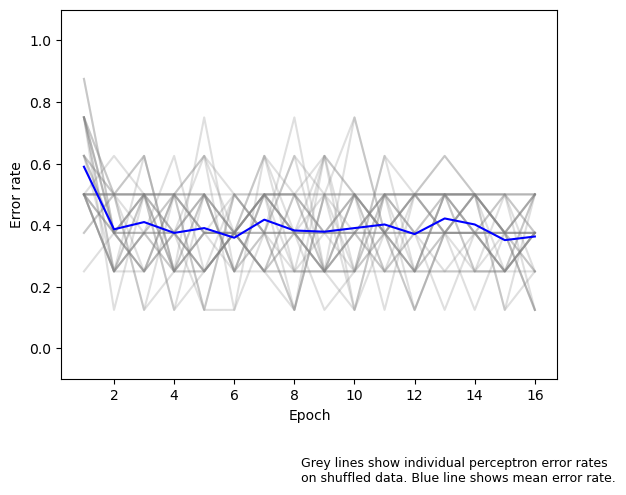

In [157]:
plot_learning_curve(error_mat)

## Task 5 - Results

Summarise the results of your Perceptron experiment. What did you notice? Can you compare the performance (error rate) with that of the study? Why or why not? 

Discuss and interpret the observations you made during the experiment.

My simulation showed that the perceptron can easily learn with the linearly separable task (class 1), reaching an error rate of 0.0. As for the non-linearly separable task (class 2) it failed. The error rate never reached 0.0, leaving a high remaining error rate.

In the study by Medin and Schwanenflugel (1981) the result showed that both tasks were equal difficulty for humans. While my NLS perceptrons failed, 23 of 32 humans in the NLS group succesfully met the learning criterion, compared to 21 of 32 in the LS group. The error performance was slightly better in the NLS group as well with an average of 30.9 errors.

These results show that linear separability is a mathematical rule for the Perceptron, but not for the human brain. The perceptron can only solve tasks where it can draw a straight line between groups. Humans are more flexible and don't just rely on this linear rule to categorize information.

## Task 6 - Further thinking

Finally, think about the following questions:

Is the perceptron a good model for human category learning? Why? Why not? 

Is the way the perceptron learns the logical rule AND the same as humans? 

The perceptron is not a sufficient model for human learning. My simulation showed that it fails on non-linear tasks, however the study by Medin and Schwanenflugel proved that humans can solve these tasks easily. Because humans are more flexible and can use more complex strategies than a perceptron. 

The learning processes are different. The perceptron follows a mathematical rule and is adding up cues. Humans likely use an "exemplar - based" approach. As Medin and Schwanenflugel argued, humans are influenced by the similarity between objects, we compare new items to stored representations of previous items. This allows us to have a more advanced way of thinking than the perceptron's logic.